In [1]:
%load_ext autoreload
%autoreload 2

from ml.surrogate import SurrogateInversion, train_surrogate, Surrogate
from simulation.make_dataset import make_dataset
from constants import *

import torch as t
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as patches
from typing import Optional, Tuple
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.size": 11, "figure.dpi": 140})

In [2]:
# Fixed values for plotting
phys = PhysicsConstants()
params = SimulationParameters()
dataset = DatasetParameters(filename= "ml_fig_dataset.npz")


In [15]:
make_dataset(phys, params, dataset)
ml_params = MLParameters(data_filepath="/u/mgalexan/NPSurr/data/ml_fig_dataset.npz", save_path="/u/mgalexan/NPSurr/data/fig_model.pt")
train_hist, val_hist = train_surrogate(ml_params) 

d_val_m:   0%|          | 0/81 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [3]:
model = t.load("/u/mgalexan/NPSurr/data/cin_model.pt", weights_only=False)
d_vals = np.linspace(20, 80, 25) * 1e-9
k_rel_vals = np.logspace(-6, -2, 25)
inv = SurrogateInversion(model, InversionParameters(), phys, params)



In [18]:
L_surrs = []; L_pdes = []
points = [
    (35e-9, 2e-6),
    (55e-9, 1e-5),
    (75e-9, 5e-5)
]
for d_val_m, k_rel in points: 
    phys = PhysicsConstants(d_val_m= d_val_m, k_rel = k_rel)
    obs_dataset_params = DatasetParameters(    
        d_val_m= np.array([d_val_m]),
        k_rel= np.array([k_rel]),
        save= False
    )
    obs_dataset = make_dataset(phys, params, obs_dataset_params)
    obs_dataset["CN"] = obs_dataset["CN"][0,0]; obs_dataset["CF"] = obs_dataset["CF"][0,0]; obs_dataset["CI"] = obs_dataset["CI"][0,0]
    L_surrs.append(inv.loss_surface(obs_dataset, d_vals, k_rel_vals))
    L_pdes.append(inv.pde_misfit_surface(obs_dataset, d_vals, k_rel_vals))

100%|██████████| 25/25 [02:30<00:00,  6.01s/it]


In [4]:
def plot_surrogate_landscape_grid(
        L_surrs: list[ np.ndarray ],
        L_pdes: list[ np.ndarray ],
        d_grid: np.ndarray,
        k_rel_grid: np.ndarray,
        pred_points: list[tuple[float, float]],
        true_points: Optional[list[tuple[float, float]]] = None,
        fig: Optional[plt.Figure] = None,
        axes: Optional[np.ndarray] = None,
        surr_norm: Optional[colors.Normalize] = None,
        pde_norm: Optional[colors.Normalize] = None,
    ) -> tuple[plt.Figure, np.ndarray]:

        n = len(pred_points)
        if true_points is None:
            true_points = n * [None]
        if fig is None or axes is None:
                # Use gridspec_kw to increase horizontal spacing between columns and
                # disable constrained_layout so gridspec spacing takes effect.
                fig, axes = plt.subplots(2, n, figsize=(3.0 * n, 6.0), sharex=True, sharey=True, gridspec_kw={'wspace': 0.25, 'hspace': 0.15}, constrained_layout=False)

        if axes.ndim == 1:
            axes = axes.reshape(2, -1)

        # Convert surrogate log-loss back to raw values and clean arrays
        surr_clean_list = [np.where(np.isfinite(L) & (np.exp(L) >= 0), np.exp(L), np.nan) for L in L_surrs]
        pde_clean_list = [np.where(np.isfinite(L) & (L >= 0), L, np.nan) for L in L_pdes]

        # Compute separate normalization for surrogate and PDE rows
        surr_all = np.concatenate([arr.ravel() for arr in surr_clean_list])
        surr_finite = surr_all[np.isfinite(surr_all)]
        if surr_norm is None:
            if surr_finite.size > 0:
                surr_norm = colors.Normalize(vmin=surr_finite.min(), vmax=surr_finite.max())
            else:
                surr_norm = colors.Normalize(vmin=0.0, vmax=1.0)

        pde_all = np.concatenate([arr.ravel() for arr in pde_clean_list])
        pde_finite = pde_all[np.isfinite(pde_all)]
        if pde_norm is None:
            if pde_finite.size > 0:
                pde_norm = colors.Normalize(vmin=pde_finite.min(), vmax=pde_finite.max())
            else:
                pde_norm = colors.Normalize(vmin=0.0, vmax=1.0)

        x = d_grid * 1e9
        y = k_rel_grid

        # Keep track of last pcm handles (one per row) to build colorbars
        last_pcm_surr = None
        last_pcm_pde = None

        for col, (ax_surf, ax_pde, L_surf_clean, L_pde_clean, true_pt, pred_pt) in enumerate(zip(axes[0], axes[1], surr_clean_list, pde_clean_list, true_points, pred_points)):
            last_pcm_surr = ax_surf.pcolormesh(
                x,
                y,
                L_surf_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm="log",
            )
            ax_surf.contour(
                x,
                y,
                L_surf_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_surf.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1],
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
            )
            ax_surf.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1],
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            if true_pt:
                ax_surf.set_title(rf"$d={true_pt[0]*1e9:.0f}\ \mathrm{{nm}},\ k_r={true_pt[1]}\ \mathrm{{1/s}}$" + "\nSurrogate")
            ax_surf.grid(alpha=0.25)
            ax_surf.legend(fontsize=9, loc="upper right", frameon= True)

            last_pcm_pde = ax_pde.pcolormesh(
                x,
                y,
                L_pde_clean.T,
                cmap="RdYlBu_r",
                shading="auto",
                norm="log",
            )
            ax_pde.contour(
                x,
                y,
                L_pde_clean.T,
                levels=18,
                colors="k",
                linewidths=0.4,
                alpha=0.35,
            )
            if true_pt:
                ax_pde.scatter(
                    true_pt[0] * 1e9,
                    true_pt[1],
                    c="cyan",
                    s=120,
                    marker="*",
                    edgecolors="k",
                    linewidths=0.8,
                    label="Data point",
                    zorder=6,
                )
            ax_pde.scatter(
                pred_pt[0] * 1e9,
                pred_pt[1],
                c="red",
                s=90,
                marker="x",
                linewidths=2.5,
                label="Estimated point",
                zorder=6,
            )
            ax_pde.set_title("PDE")
            ax_pde.grid(alpha=0.25)
            ax_pde.legend(fontsize=9, loc="upper right", frameon= True)

        for ax in axes[1, :]:
            ax.set_xlabel(r"$d$ (nm)")
        for ax in axes[:, 0]:
            ax.set_ylabel(r"$k_r$")
        for ax in axes.flatten():
            ax.set_yscale("log")

        fig.suptitle("Surrogate vs PDE loss landscape per evaluated point", fontsize=16, y=1.02)

        # Create compact colorbars adjacent to the last column of each row
        if last_pcm_surr is not None:
            divider = make_axes_locatable(axes[0, -1])
            cax_surr = divider.append_axes("right", size="3%", pad=0.1)
            cbar_surr = fig.colorbar(last_pcm_surr, cax=cax_surr)
            cbar_surr.set_label(r"$\mathcal{L}_{surr}$")
        if last_pcm_pde is not None:
            divider = make_axes_locatable(axes[1, -1])
            cax_pde = divider.append_axes("right", size="3%", pad=0.1)
            cbar_pde = fig.colorbar(last_pcm_pde, cax=cax_pde)
            cbar_pde.set_label(r"$\mathcal{L}_{PDE}$")

        return fig, axes


pred_points = []
for d_val_m, k_rel in points:
    phys = PhysicsConstants(d_val_m=d_val_m, k_rel= k_rel)
    obs_dataset_params = DatasetParameters(
        d_val_m=np.array([d_val_m]),
        k_rel=np.array([k_rel]),
        save=False,
    )
    obs_dataset = make_dataset(phys, params, obs_dataset_params)
    obs_dataset["CN"] = obs_dataset["CN"][0, 0]
    obs_dataset["CF"] = obs_dataset["CF"][0, 0]
    obs_dataset["CI"] = obs_dataset["CI"][0, 0]
    result = inv.invert(obs_dataset)
    pred_points.append(tuple(result))

fig, axes = plot_surrogate_landscape_grid(
    L_surrs,
    L_pdes,
    d_vals,
    k_rel_vals,
    pred_points,
    points,
)
fig._suptitle.remove()

plt.show()

NameError: name 'points' is not defined

In [5]:
# Generate a uniform dosage
phys_const = PhysicsConstants()
dataset_params_const = DatasetParameters(
    save=False,
    d_val_m=np.array([phys_const.d_val_m]),
    k_rel= np.array([phys_const.k_rel])
)
data_const = make_dataset(phys_const, params, dataset_params_const)
CI = data_const["CI"][0,0]
x = np.linspace(0, 1, CI.shape[1])
mins = CI.min(axis=1, keepdims=True) + 1e-10
maxs = CI.max(axis=1, keepdims=True) + 1e-10
f = np.log(mins) + (np.log(maxs) - np.log(mins)) * x
CI_new = np.exp(f)
data_const["CI"] = CI_new
const_res = inv.invert(data_const)

L_surr = inv.loss_surface(data_const, d_vals, k_rel_vals)
L_pde = inv.pde_misfit_surface(data_const, d_vals, k_rel_vals)
data_res = DatasetParameters(
    save=False,
    d_val_m= const_res[:1],
    k_rel= const_res[1:]
)
retrieved_data = make_dataset(phys_const, params, data_res)
retrieved_data["CI"] = retrieved_data["CI"][0,0]


d_val_m:   0%|          | 0/1 [00:00<?, ?it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  4.91it/s]


KeyboardInterrupt: 

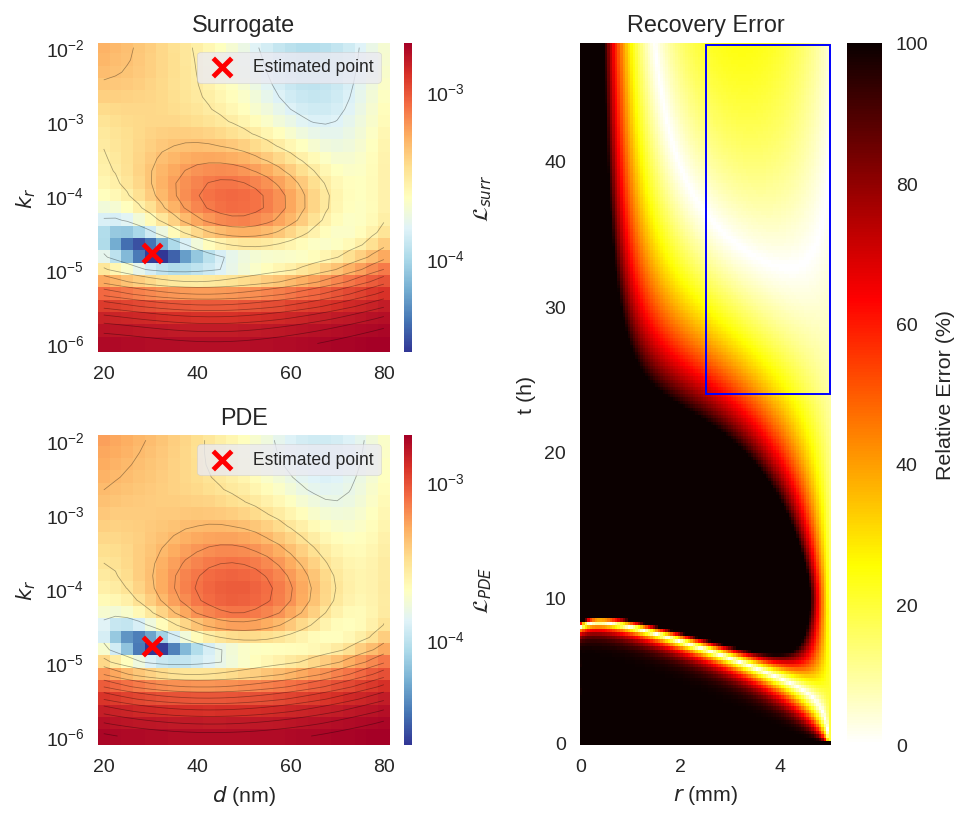

In [8]:
shape = [["C", "E"], ["D", "E"]]
fig, axd = plt.subplot_mosaic(shape, figsize= (7, 6))

plot_surrogate_landscape_grid(
    [L_surr],
    [L_pde],
    d_vals,
    k_rel_vals,
    [const_res],
    fig=fig,
    axes = np.array([axd["C"], axd["D"]])
)
axd["C"].set_title("Surrogate")

rel = np.abs(retrieved_data["CI"] - data_const["CI"]) * 100 / data_const["CI"]
rel.astype(np.int32)

r_vals = retrieved_data["r"] * 1000
t_vals = retrieved_data["t_out"] / 3600

t_idx_1 = 50
t_val_1 = retrieved_data["t_out"][t_idx_1] / 3600
'''
axd["A"].semilogy(r_vals, retrieved_data["CI"][t_idx_1], linestyle="--", color= "orange", label="Retrieved")
axd["A"].semilogy(r_vals, data_const["CI"][t_idx_1], color= "blue", label= "Target")
axd["A"].set_title(f"Profile Comparison at t={t_val_1:.0f}h")
axd["A"].set_ylabel(r"$C_I$ (mol)")
axd["A"].legend()

t_idx_2 = 100
t_val_2 = retrieved_data["t_out"][t_idx_2] / 3600
axd["B"].semilogy(r_vals, retrieved_data["CI"][t_idx_2], linestyle="--", color= "orange", label= "Retrieved")
axd["B"].semilogy(r_vals, data_const["CI"][t_idx_2], color= "blue", label= "Target")
axd["B"].set_title(f"Profile Comparison at t={t_val_2:.0f}h")
axd["B"].set_ylabel(r"$C_I$ (mol)")
axd["B"].legend()
axd["B"].set_xlabel(r"$r$ (mm)")
'''
err_rect = patches.Rectangle((2.5, 24), 2.5, 24, linewidth=1, edgecolor='b', facecolor="none")

err = axd["E"].pcolormesh(r_vals, t_vals, rel, cmap="hot_r", vmax= 100, vmin= 0)
axd["E"].add_patch(err_rect)
axd["E"].set_xlabel(r"$r$ (mm)")
axd["E"].set_ylabel(r"t (h)")
axd["E"].set_title("Recovery Error")
cbar_err = fig.colorbar(err)
cbar_err.set_label("Relative Error (%)")
fig._suptitle.remove()
fig.tight_layout()

In [23]:
# Loss landscapes for maximizing fkc
L_surr_fkc = inv.loss_surface(data_const, d_vals, k_rel_vals, "CI_center")
L_pde_fkc = inv.pde_misfit_surface(data_const, d_vals, k_rel_vals, "CI_center")

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [02:29<00:00,  5.99s/it]


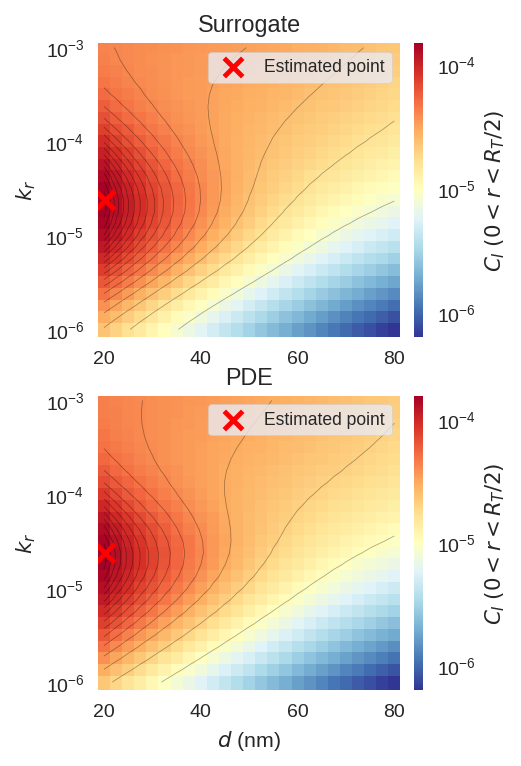

In [24]:
fkc_res = inv.invert(data_const, "CI_center")
fig, ax = plt.subplots(2, 1, figsize= (3, 6))
plot_surrogate_landscape_grid(
    [L_surr_fkc],
    [L_pde_fkc],
    d_vals,
    k_rel_vals,
    [fkc_res],
    fig = fig, 
    axes = ax
)
fig._suptitle.remove()
ax[0].set_title("Surrogate")
ax[1].set_title("PDE")
im = ax[0].collections[0]
cbar = im.colorbar
cbar.set_label(r"$C_I$ $(0 < r < R_T/2)$")
im = ax[1].collections[0]
cbar = im.colorbar
cbar.set_label(r"$C_I$ $(0 < r <R_T/2)$")
plt.show()

In [6]:
sigma_d_vals = [10e-9, 20e-9, 40e-9]
d_opt_vals = [30e-9, 50e-9, 70e-9]

P0_vals = [1e-10, 1e-9, 1e-8]
d_pore_vals = [80e-9, 150e-9, 300e-9]
xi_ECM_vals = [25e-9, 60e-9, 120e-9]


sigma_d_ordered = []
d_opt_ordered = []
d_pore_ordered = []
phys_list = []
model_list = []
inv_list = []
labels = []

for d_opt in d_opt_vals:
    for sigma_d in sigma_d_vals:
        for i in range(len(d_pore_vals)):
            d_pore = d_pore_vals[i]
            xi_ECM = xi_ECM_vals[i]
            P0 = P0_vals[i]
            sigma_d_ordered.append(sigma_d)
            d_opt_ordered.append(d_opt)
            d_pore_ordered.append(d_pore)
            labels.append(f"d_opt={d_opt:.2g}, sigma_d={sigma_d:.2g}, d_pore={d_pore:.2g}")
            phys_list.append(PhysicsConstants(P0= P0, d_pore=d_pore, xi_ECM=xi_ECM, d_opt=d_opt, sigma_d=sigma_d))
            model_list.append(t.load(f"/u/mgalexan/NPSurr/data/d_opt={d_opt:.2g}_sigma_d={sigma_d:.2g}_d_pore={d_pore:.2g}_model.pt", weights_only= False))
            inv_list.append(SurrogateInversion(model_list[-1], InversionParameters(), phys_list[-1], params))



In [7]:
from p_tqdm import p_map

/u/mgalexan/NPSurr/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
surr_maker = lambda i: i.loss_surface(data_const, d_vals, k_rel_vals, "CI")
pde_maker = lambda i : i.pde_misfit_surface(data_const, d_vals, k_rel_vals, "CI")
res_maker = lambda i : i.invert(data_const, "CI")

L_surr_list = p_map(surr_maker, inv_list)
L_pde_list = p_map(pde_maker, inv_list)
res_list = p_map(res_maker, inv_list)

100%|██████████| 27/27 [00:09<00:00,  2.86it/s]


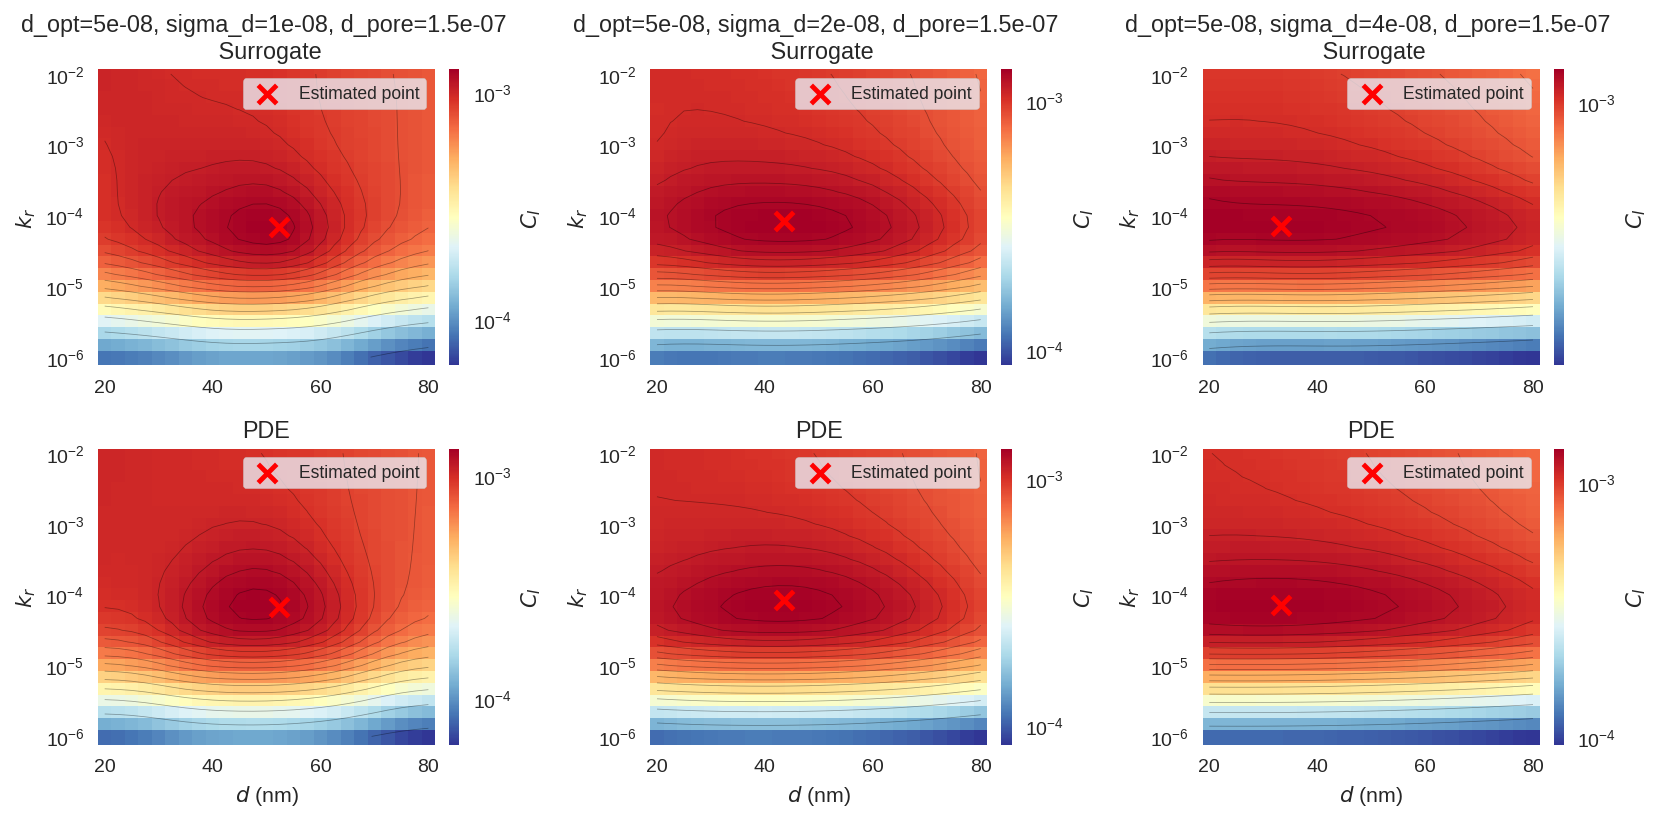

In [17]:
panel1 = 10
panel2 = 13
panel3 = 16

fig, ax = plt.subplots(2, 3, figsize= (12, 6))
plot_surrogate_landscape_grid(
    [L_surr_list[panel1]],
    [L_pde_list[panel1]],
    d_vals,
    k_rel_vals,
    [res_list[panel1]],
    fig = fig, 
    axes = ax[:,0]
)
plot_surrogate_landscape_grid(
    [L_surr_list[panel2]],
    [L_pde_list[panel2]],
    d_vals,
    k_rel_vals,
    [res_list[panel2]],
    fig = fig, 
    axes = ax[:,1]
)
plot_surrogate_landscape_grid(
    [L_surr_list[panel3]],
    [L_pde_list[panel3]],
    d_vals,
    k_rel_vals,
    [res_list[panel3]],
    fig = fig, 
    axes = ax[:,2]
)
fig._suptitle.remove()
ax[0, 0].set_title(f"{labels[panel1]} \n Surrogate")
ax[0, 1].set_title(f"{labels[panel2]} \n Surrogate")
ax[0, 2].set_title(f"{labels[panel3]} \n Surrogate")
for i in range(3):
    ax[1, i].set_title("PDE")
for i in range(2):
    for j in range(3):
        im = ax[i, j].collections[0]
        cbar = im.colorbar
        cbar.set_label(r"$C_I$")
plt.tight_layout()
plt.show()

In [20]:
for i, label in enumerate(labels):
    print(f"Optimal parameters for {label}:  d = {res_list[i][0] * 1e9:.3f} nm, k_rel = {res_list[i][1]:.3g}")
d_res_list = [res[0] * 1e9 for res in res_list]

Optimal parameters for d_opt=3e-08, sigma_d=1e-08, d_pore=8e-08:  d = 24.572 nm, k_rel = 7.97e-05
Optimal parameters for d_opt=3e-08, sigma_d=1e-08, d_pore=1.5e-07:  d = 30.697 nm, k_rel = 7.26e-05
Optimal parameters for d_opt=3e-08, sigma_d=1e-08, d_pore=3e-07:  d = 29.329 nm, k_rel = 9.69e-05
Optimal parameters for d_opt=3e-08, sigma_d=2e-08, d_pore=8e-08:  d = 20.147 nm, k_rel = 9.86e-05
Optimal parameters for d_opt=3e-08, sigma_d=2e-08, d_pore=1.5e-07:  d = 20.321 nm, k_rel = 9.2e-05
Optimal parameters for d_opt=3e-08, sigma_d=2e-08, d_pore=3e-07:  d = 20.168 nm, k_rel = 0.000104
Optimal parameters for d_opt=3e-08, sigma_d=4e-08, d_pore=8e-08:  d = 21.305 nm, k_rel = 6.61e-05
Optimal parameters for d_opt=3e-08, sigma_d=4e-08, d_pore=1.5e-07:  d = 20.605 nm, k_rel = 8.58e-05
Optimal parameters for d_opt=3e-08, sigma_d=4e-08, d_pore=3e-07:  d = 20.198 nm, k_rel = 0.000153
Optimal parameters for d_opt=5e-08, sigma_d=1e-08, d_pore=8e-08:  d = 47.707 nm, k_rel = 7.14e-05
Optimal paramet

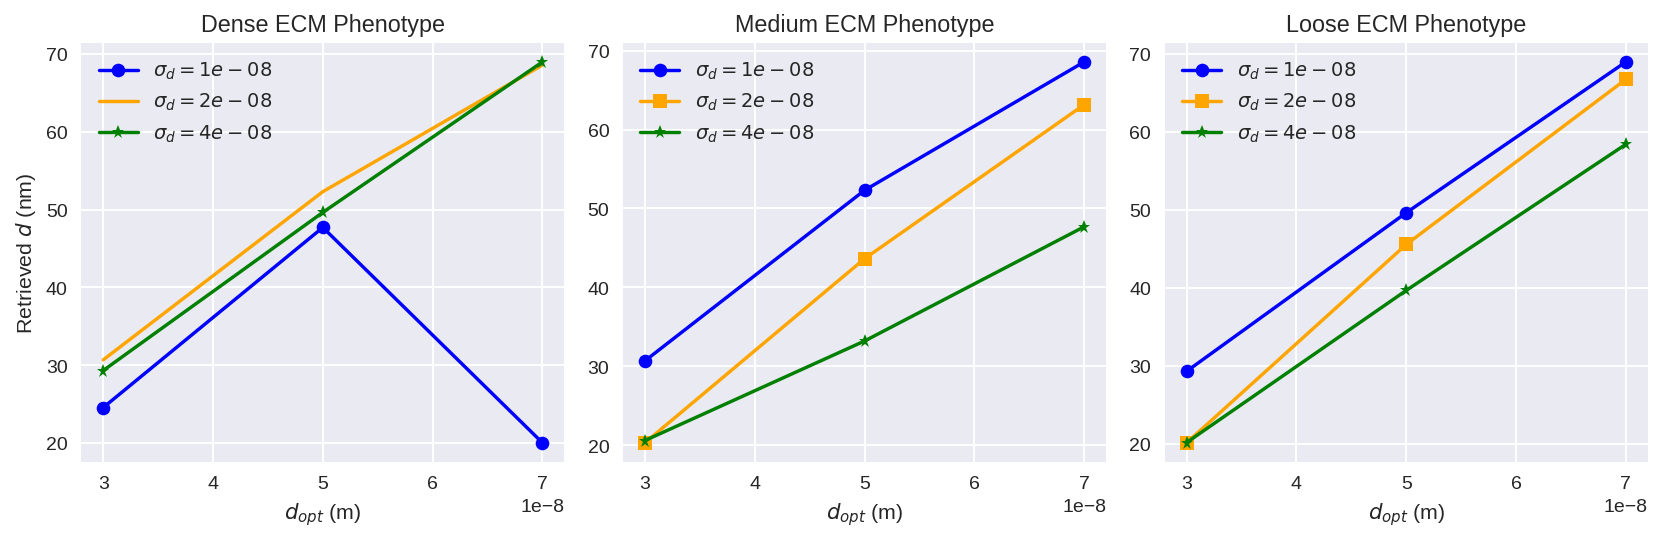

In [ ]:
fig, ax = plt.subplots(1, 3, figsize= (12, 4))
ax[0].plot(d_opt_ordered[::9], d_res_list[::9], 'o-', color= "blue", label= rf"$\sigma_d={sigma_d_ordered[0]:.2g}$")
ax[0].plot(d_opt_ordered[3::9], d_res_list[1::9], 's-', color= "orange", label= rf"$\sigma_d={sigma_d_ordered[3]:.2g}$")
ax[0].plot(d_opt_ordered[6::9], d_res_list[2::9], '*-', color= "green", label= rf"$\sigma_d={sigma_d_ordered[6]:.2g}$")
ax[0].legend()
ax[0].set_xlabel(r"$d_{opt}$ (m)")
ax[0].set_ylabel(r"Retrieved $d$ (nm)")
ax[0].set_title("Dense ECM Phenotype")
ax[1].plot(d_opt_ordered[1::9], d_res_list[1::9], 'o-', color= "blue", label= rf"$\sigma_d={sigma_d_ordered[1]:.2g}$")
ax[1].plot(d_opt_ordered[4::9], d_res_list[4::9], 's-', color= "orange", label= rf"$\sigma_d={sigma_d_ordered[4]:.2g}$")
ax[1].plot(d_opt_ordered[7::9], d_res_list[7::9], '*-', color= "green", label= rf"$\sigma_d={sigma_d_ordered[7]:.2g}$")
ax[1].legend()
ax[1].set_xlabel(r"$d_{opt}$ (m)")
ax[1].set_title("Medium ECM Phenotype")
ax[2].plot(d_opt_ordered[2::9], d_res_list[2::9], 'o-', color= "blue", label= rf"$\sigma_d={sigma_d_ordered[2]:.2g}$")
ax[2].plot(d_opt_ordered[5::9], d_res_list[5::9], 's-', color= "orange", label= rf"$\sigma_d={sigma_d_ordered[5]:.2g}$")
ax[2].plot(d_opt_ordered[8::9], d_res_list[8::9], '*-', color= "green", label= rf"$\sigma_d={sigma_d_ordered[8]:.2g}$")
ax[2].legend()
ax[2].set_xlabel(r"$d_{opt}$ (m)")
ax[2].set_title("Loose ECM Phenotype")
plt.tight_layout()


